In [1]:
import pandas as pd
from matplotlib.pyplot import  plot

In [2]:
data=pd.read_excel('./horizontal_signals.xlsx')

In [3]:
data

,151,151.1,161,143,152,134,127,123,138,135,139,122,126,129,125,129.1,135.1,139.1,135.2,133
0,145,146,163,136,147,141,133,132,131,136,145,133,127,131,122,135,130,131,127,134
1,146,146,164,136,152,138,137,135,132,138,149,130,122,138,127,138,134,135,134,132
2,151,152,158,141,151,131,130,124,140,133,145,123,126,131,126,133,136,134,136,131
3,151,147,161,137,148,139,129,132,133,135,141,132,130,131,121,131,129,137,128,133
4,148,148,162,141,147,143,134,133,136,136,147,129,127,137,129,139,126,129,130,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,138,147,117,128,152,135,143,132,136,145,139,145,135,137,140,140,139,134,138,136
246,140,148,115,132,153,139,142,143,138,145,135,146,131,140,140,144,131,139,144,128
247,139,146,121,127,151,133,147,142,143,140,130,136,140,144,137,139,136,140,148,133
248,137,146,116,131,154,134,137,130,137,140,133,141,140,134,141,137,144,135,139,131


In [4]:
names=data.iloc[-1]

In [5]:
data=data.iloc[:-1]

In [6]:
data

,151,151.1,161,143,152,134,127,123,138,135,139,122,126,129,125,129.1,135.1,139.1,135.2,133
0,145,146,163,136,147,141,133,132,131,136,145,133,127,131,122,135,130,131,127,134
1,146,146,164,136,152,138,137,135,132,138,149,130,122,138,127,138,134,135,134,132
2,151,152,158,141,151,131,130,124,140,133,145,123,126,131,126,133,136,134,136,131
3,151,147,161,137,148,139,129,132,133,135,141,132,130,131,121,131,129,137,128,133
4,148,148,162,141,147,143,134,133,136,136,147,129,127,137,129,139,126,129,130,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,136,145,118,126,152,130,149,140,143,137,129,134,140,135,136,138,141,133,146,129
245,138,147,117,128,152,135,143,132,136,145,139,145,135,137,140,140,139,134,138,136
246,140,148,115,132,153,139,142,143,138,145,135,146,131,140,140,144,131,139,144,128
247,139,146,121,127,151,133,147,142,143,140,130,136,140,144,137,139,136,140,148,133


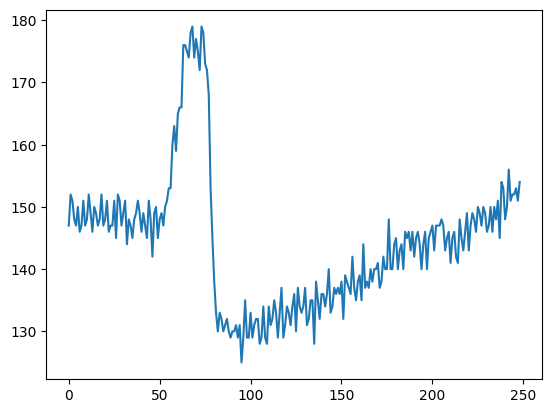

In [7]:
plot(data.iloc[:,4])

mean

In [8]:
data.iloc[:,0].mean()

np.float64(139.14859437751005)

standard diviation

In [9]:
data.iloc[:,0].std()

np.float64(15.14253542391913)

max peak value

In [10]:
data.iloc[:,0].max()

186

AUC (Area under the curve)

In [11]:
import scipy

In [12]:
scipy.integrate.simpson(data.iloc[:,0])

34495.33333333333

Auto regression

In [13]:
from statsmodels.tsa.ar_model import AutoReg

In [14]:
import numpy as np

In [15]:
model=AutoReg(np.array(data.iloc[:,0]),lags=2)

In [16]:
model.fit().params

array([3.76770808, 0.87865286, 0.09398906])

In [17]:
featuresMatrix={
    'mean':[],
    'std':[],
    'maxPeakValue':[],
    'AUC':[],
    'AutoReg0':[],
    'AutoReg1':[],
    'AutoReg2':[]
}

In [18]:
for col in range(data.shape[1]):
    signal = np.array(data.iloc[:, col])
    arParams = AutoReg(signal, lags=2).fit().params
    featuresMatrix['mean'].append(data.iloc[:,col].mean())
    featuresMatrix['std'].append(data.iloc[:,col].std())
    featuresMatrix['maxPeakValue'].append(data.iloc[:,col].max())
    featuresMatrix['AUC'].append(scipy.integrate.simpson(data.iloc[:,col]))
    featuresMatrix['AutoReg0'].append(arParams[0])
    featuresMatrix['AutoReg1'].append(arParams[1])
    featuresMatrix['AutoReg2'].append(arParams[2])

In [19]:
featuresMatrixDF=pd.DataFrame(featuresMatrix)

In [20]:
featuresMatrixDF

,mean,std,maxPeakValue,AUC,AutoReg0,AutoReg1,AutoReg2
0,139.148594,15.142535,186,34495.333333,3.767708,0.878653,0.093989
1,146.429719,11.544972,187,36308.000000,6.561535,0.813827,0.141364
2,148.469880,22.500002,180,36835.000000,0.543525,0.696165,0.298526
3,143.947791,18.621259,191,35727.000000,2.039972,0.793625,0.192022
4,144.305221,11.103400,179,35768.333333,5.894405,0.668673,0.290555
5,136.887550,14.320475,155,33961.000000,8.283333,0.716047,0.223268
6,133.983936,12.509663,156,33224.666667,12.513145,0.635371,0.271345
7,130.979920,11.400852,147,32480.000000,16.792585,0.633838,0.237873
8,131.598394,12.468968,148,32630.666667,13.426651,0.657400,0.240800
9,138.273092,11.528266,152,34293.333333,9.016461,0.750527,0.184347


In [21]:
featuresMatrixDF.to_excel("Features-Matrix.xlsx",index=False)

In [22]:
test=np.array([])

In [23]:
with open('./test_signal.txt','r') as f:
    test=f.read()

In [24]:
test = np.array(list(map(int, test.split("\n"))))

In [25]:
test

array([134, 141, 138, 131, 139, 143, 134, 137, 141, 131, 135, 142, 140,
       133, 141, 142, 134, 142, 144, 139, 134, 141, 136, 131, 138, 138,
       129, 133, 137, 128, 133, 133, 127, 127, 135, 130, 127, 131, 133,
       123, 127, 133, 132, 127, 132, 135, 128, 132, 132, 130, 131, 135,
       129, 129, 131, 134, 132, 133, 139, 131, 138, 136, 133, 134, 136,
       129, 132, 143, 134, 128, 138, 135, 132, 137, 141, 135, 133, 139,
       139, 132, 137, 139, 127, 139, 139, 132, 136, 139, 137, 131, 142,
       139, 133, 137, 141, 134, 134, 125, 121, 112, 117, 109, 100, 101,
       100,  91,  90,  92,  85,  92,  90,  87,  93,  93,  88,  94,  93,
        96, 107, 114, 129, 145, 147, 146, 152, 153, 142, 145, 144, 141,
       143, 147, 143, 141, 146, 146, 142, 146, 150, 143, 142, 149, 143,
       143, 150, 152, 141, 149, 152, 143, 147, 149, 149, 142, 153, 148,
       140, 150, 152, 145, 150, 154, 144, 146, 152, 147, 144, 147, 150,
       145, 145, 152, 145, 148, 152, 150, 148, 151, 152, 145, 15

In [26]:
testArParams = AutoReg(test, lags=2).fit().params
testFeatures=np.array([
    test.mean(),
    test.std(),
    test.max(),
    scipy.integrate.simpson(test),
    testArParams[0],
    testArParams[1],
    testArParams[2]])

In [27]:
from scipy.spatial.distance import euclidean

In [28]:
featuresMatrixDF.iloc[0].values

array([1.39148594e+02, 1.51425354e+01, 1.86000000e+02, 3.44953333e+04,
       3.76770808e+00, 8.78652861e-01, 9.39890578e-02])

In [29]:
featureMeans = featuresMatrixDF.mean()
featureStds = featuresMatrixDF.std()
featuresMatrixScaled = (featuresMatrixDF - featureMeans) / featureStds
testFeaturesScaled = (testFeatures - featureMeans.values) / featureStds.values

minD = euclidean(testFeaturesScaled, featuresMatrixScaled.iloc[0].values)
match = 0

In [30]:
for i in range(data.shape[1]):
    d = euclidean(testFeaturesScaled, featuresMatrixScaled.iloc[i].values)
    if d < minD:
        minD = d
        match = i

In [31]:
names

151        Adam
151.1     Layan
161        Zayn
143       Mayar
152      Rayyan
134        Juri
127       Faris
123        Tala
138        Kian
135        Ayla
139       Hamza
122       Randa
126       Yazan
129        Naya
125        Omar
129.1     Dalia
135.1     Bader
139.1      Lina
135.2     Layth
133        Haya
Name: 249, dtype: object

In [32]:
names.iloc[match]

'Juri'